# Day 2 · Lab — Inside a Transformer + Classical-vs-LLM Bake-off
**Goal:** see **tokens → embeddings → attention** on a real model, then compare classical
and transformer-style features on the same classification task.

**Why this lab matters:** this is a systems trade-off exercise (quality, latency, and cost).

**Focus:**
- Follow the same pipeline each time: input text -> features -> model -> metric.
- Use results to justify Keep / Augment / Replace.

In [ ]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

# Load a small pretrained transformer and tokenizer for CPU demos.
NAME = 'distilbert-base-uncased'
tok = AutoTokenizer.from_pretrained(NAME)
model = AutoModel.from_pretrained(NAME, output_attentions=True).eval()

# Resolve dataset path robustly for different working directories.
DATA = next((p for p in ('datasets', '../datasets', '../../datasets') if os.path.isdir(p)), None)
if DATA is None:
    raise FileNotFoundError("Could not find a datasets directory. Tried: datasets, ../datasets, ../../datasets")

# Focus: number of layers and heads defines attention visualization range.
print('layers:', model.config.n_layers, '| heads:', model.config.n_heads)

layers: 6 | heads: 12


## Part 1 — Tokenization
Transformers read **tokens**, not words. Rare/long words split into **subwords** (`##`).

**Focus:** check how one sentence becomes a token list and token IDs.

In [ ]:
#msg = "I still haven't received my refund for the cancelled order."
msg = "I did not get my refund because the order was cancelled."

# Tokenize text into model inputs (IDs + attention mask).
enc = tok(msg, return_tensors='pt')
print('n tokens:', enc)

# Convert token IDs back to readable tokens for inspection.
tokens = tok.convert_ids_to_tokens(enc['input_ids'][0])
print('n tokens:', len(tokens))
print(tokens)

n tokens: {'input_ids': tensor([[  101,  1045,  2106,  2025,  2131,  2026, 25416,  8630,  2138,  1996,
          2344,  2001,  8014,  1012,   102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
n tokens: 15
['[CLS]', 'i', 'did', 'not', 'get', 'my', 'ref', '##und', 'because', 'the', 'order', 'was', 'cancelled', '.', '[SEP]']


### Exercise 1 — subwords
Tokenize **'reactivation'** with `tok.tokenize(...)`.

**Focus:** count pieces and notice `##` continuation tokens.

In [ ]:
# Exercise: inspect subword splitting behavior.
pieces = tok.tokenize('explain the difference between a transformer and a recurrent neural network')
print(pieces)

['explain', 'the', 'difference', 'between', 'a', 'transform', '##er', 'and', 'a', 'rec', '##urrent', 'neural', 'network']


---
> ⏸️ **Break — end of Lab part 1.** Before moving on, confirm you can explain tokenization output clearly.

## Part 2 — Embeddings & attention
Mean-pool the model output vectors into a **sentence embedding**, then compare meaning
with **cosine similarity**.

**Focus:** similar messages should score higher than different-topic messages.

In [ ]:
tickets = pd.read_csv(os.path.join(DATA, 'support_tickets_sample.csv'))

def embed(text):
    # Build tokenized input for one sentence.
    enc = tok(text, return_tensors='pt', truncation=True)
    with torch.no_grad():
        out = model(**enc)
    # Mean-pool token vectors, masked to ignore padding.
    mask = enc['attention_mask'].unsqueeze(-1)
    return (out.last_hidden_state * mask).sum(1).squeeze(0) / mask.sum()

a = 'I want my money back for this order'
b = 'please process a refund to my card'
c = 'where is my package, it has not arrived'

# Focus: similar meaning pair should have higher cosine score.
print('a,b (both refund) cos =', round(F.cosine_similarity(embed(a), embed(b), dim=0).item(), 3))
print('a,c (diff topic) cos =', round(F.cosine_similarity(embed(a), embed(c), dim=0).item(), 3))

a,b (both refund) cos = 0.793
a,c (diff topic) cos = 0.599


### Exercise 2 — nearest ticket
Embed `query` and every `customer_message`; print the most similar ticket.

**Focus:** this is a simple semantic retrieval pattern (vector similarity search).

In [ ]:
query = 'I was charged twice on my invoice'
qv = embed(query)

# Compute cosine similarity of query vs every ticket message.
sims = [F.cosine_similarity(qv, embed(t), dim=0).item() for t in tickets['customer_message']]
best = max(range(len(sims)), key=lambda i: sims[i])

# Focus: this is nearest-neighbor retrieval in embedding space.
print('closest:', tickets['customer_message'].iloc[best])

closest: where to see the early termination charges?


Attention: each layer × head gives a `seq × seq` matrix — who attends to whom.

**Focus:** read rows as 'current token looking at other tokens'.

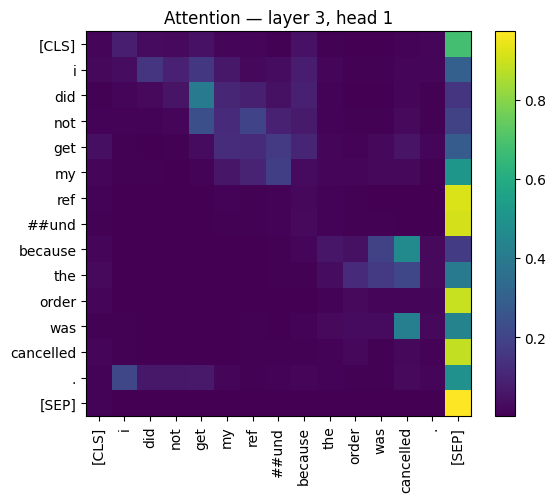

In [ ]:
# Re-tokenize current message and fetch attention tensors.
enc = tok(msg, return_tensors='pt')
tokens = tok.convert_ids_to_tokens(enc['input_ids'][0])
with torch.no_grad():
    att = model(**enc).attentions          # tuple: layers x [1, heads, seq, seq]

def plot_attention(layer, head):
    # A is seq x seq: rows=query token, cols=attended token.
    A = att[layer][0, head].numpy()
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(A, cmap='viridis')
    ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens)
    ax.set_title(f'Attention — layer {layer}, head {head}')
    fig.colorbar(im); plt.tight_layout(); plt.show()

# Focus: compare this map with other heads/layers for pattern changes.
plot_attention(layer=3, head=1)

### Exercise 3 — explore heads
Plot a different layer/head (0–5, 0–11) and note what pattern you see.

**Focus:** compare early vs later layers and local vs long-range attention.

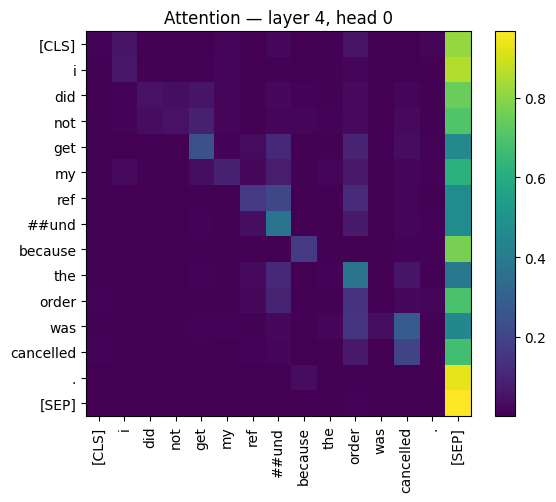

In [ ]:
# Exercise: change layer/head and compare pattern behavior.
plot_attention(layer=4, head=0)

## Part 3 — Classical vs LLM bake-off ⭐
Same task — **classify support tickets by category** — two ways. We measure **accuracy**,
**training/featurization time**, and reason about **cost**.

**Focus:** evaluate trade-offs, not only accuracy.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# Load classification dataset and create stratified train/test split.
clf_df = pd.read_csv(os.path.join(DATA, 'support_tickets_classification.csv'))
Xtr, Xte, ytr, yte = train_test_split(clf_df['text'], clf_df['category'],
    test_size=0.25, random_state=11, stratify=clf_df['category'])

# Focus: this split is reused for both approaches for fair comparison.
print('train:', len(Xtr), '| test:', len(Xte), '| classes:', clf_df['category'].nunique())

train: 480 | test: 160 | classes: 8


### Exercise 4 — the classical approach (TF-IDF + LogReg)
Build `make_pipeline(TfidfVectorizer(...), LogisticRegression(max_iter=1000))`, fit, score.

**Focus:** this is your low-cost baseline.

In [ ]:
t0 = time.perf_counter()

# Classical baseline: sparse n-gram features + linear classifier.
make_pipeline(TfidfVectorizer(ngram_range=(1,2), min_df=2),
                   LogisticRegression(max_iter=1000)).fit(Xtr, ytr)
classical = make_pipeline(TfidfVectorizer(ngram_range=(1,2), min_df=2),
                   LogisticRegression(max_iter=1000)).fit(Xtr, ytr)

classical_time = time.perf_counter() - t0
classical_acc = accuracy_score(yte, classical.predict(Xte))

# Focus: this is usually the cheapest strong baseline for text routing.
print('classical: acc=%.3f, time=%.2fs' % (classical_acc, classical_time))

classical: acc=0.975, time=0.06s


### The LLM-style approach (transformer embeddings + LogReg)
Featurize each ticket with mean-pooled DistilBERT embeddings, then fit the same classifier.

**Focus:** compare feature quality vs featurization compute cost.

In [ ]:
def embed_batch(texts, batch_size=32):
    vecs = []
    for i in range(0, len(texts), batch_size):
        chunk = list(texts[i:i + batch_size])
        enc = tok(chunk, return_tensors='pt', padding=True, truncation=True, max_length=64)
        with torch.no_grad():
            out = model(**enc).last_hidden_state
        # Mean-pool token vectors for each text row in the batch.
        mask = enc['attention_mask'].unsqueeze(-1)
        pooled = (out * mask).sum(1) / mask.sum(1)
        vecs.append(pooled.numpy())
    return np.vstack(vecs)

t0 = time.perf_counter()

# Build dense transformer embeddings for train and test text.
Etr = embed_batch(Xtr.tolist()); Ete = embed_batch(Xte.tolist())
emb_feat_time = time.perf_counter() - t0

# Train the same classifier head on richer features.
llm = LogisticRegression(max_iter=1000).fit(Etr, ytr)
llm_acc = accuracy_score(yte, llm.predict(Ete))

# Focus: compare gained accuracy against featurization compute time.
print('LLM-style: acc=%.3f, featurize_time=%.2fs' % (llm_acc, emb_feat_time))

LLM-style: acc=0.988, featurize_time=4.57s


### Compare and decide
**Focus:** use measured numbers, not intuition, for your recommendation.

In [ ]:
# Collect both approaches in one decision table.
summary = pd.DataFrame([
    {'approach': 'TF-IDF + LogReg', 'accuracy': round(classical_acc, 3),
     'fit/featurize (s)': round(classical_time, 2), 'rel. cost': 'very low'},
    {'approach': 'Transformer emb + LogReg', 'accuracy': round(llm_acc, 3),
     'fit/featurize (s)': round(emb_feat_time, 2), 'rel. cost': 'high (GPU/infra)'},
])

# Focus: this table drives your Keep / Augment / Replace decision.
print(summary.to_string(index=False))

                approach  accuracy  fit/featurize (s)        rel. cost
         TF-IDF + LogReg     0.975               0.06         very low
Transformer emb + LogReg     0.988               4.57 high (GPU/infra)


### Your call — Keep / Augment / Replace
Given the numbers above, which approach would you ship for **ticket classification**, and why?
Consider accuracy *gap* vs cost/latency at scale.

**Focus:** state one clear decision and one clear reason.

In [ ]:
# Write a short decision memo based on measured trade-offs.
decision = '''
TODO — write your Keep/Augment/Replace decision.
Typical finding: TF-IDF + LogReg is far cheaper and competitive on accuracy, so KEEP classical
for routing. AUGMENT with the LLM only if a subset of tickets needs deeper language understanding.
'''

# Focus: one recommendation + one metric-based justification.
print(decision)


TODO — write your Keep/Augment/Replace decision.
Typical finding: TF-IDF + LogReg is far cheaper and competitive on accuracy, so KEEP classical
for routing. AUGMENT with the LLM only if a subset of tickets needs deeper language understanding.



**Takeaway:** measure before choosing the expensive tool. For many text-classification
tasks, classical features are competitive at a fraction of the cost.

**Focus:** keep this decision framework for future model-selection discussions.